Dataset loaded successfully!
Dataset Shape: (54214, 4)


,id,title,genre,description
0,1,Oscar et la dame rose (2009),drama,Listening in to a conversation between his doc...
1,2,Cupid (1997),thriller,A brother and sister with a past incestuous re...
2,3,"Young, Wild and Wonderful (1980)",adult,As the bus empties the students for their fiel...
3,4,The Secret Sin (1915),drama,To help their unemployed father make ends meet...
4,5,The Unrecovered (2007),drama,The film's title refers not only to the un-rec...



Genre Distribution:
genre
drama          13613
documentary    13096
comedy          7447
short           5073
horror          2204
thriller        1591
action          1315
western         1032
reality-tv       884
family           784
adventure        775
music            731
romance          672
sci-fi           647
adult            590
crime            505
animation        498
sport            432
talk-show        391
fantasy          323
mystery          319
musical          277
biography        265
history          243
game-show        194
news             181
war              132
Name: count, dtype: int64

TF-IDF completed!
Training Shape: (43371, 50000)
Testing Shape: (10843, 50000)

Model training completed!

Accuracy: 49.92%

Classification Report:
              precision    recall  f1-score   support

      action       0.33      0.50      0.40       263
       adult       0.40      0.73      0.52       118
   adventure       0.24      0.37      0.29       155
   animation  

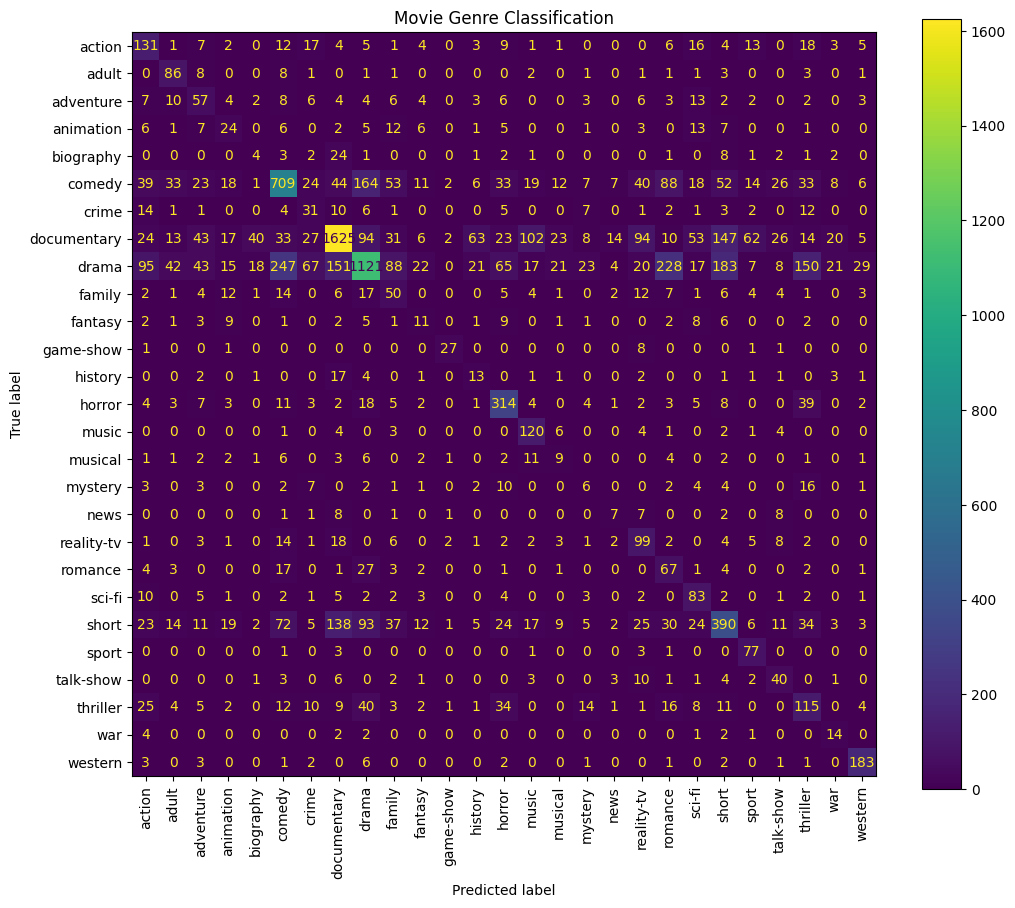


Movie Genre Predictions:

Plot: A detective investigates a mysterious murder in a small town.
Predicted Genre: mystery

Plot: Two people fall in love and face challenges in their relationship.
Predicted Genre: romance

Plot: A group of astronauts travel through space to discover a new planet.
Predicted Genre: sci-fi

Plot: A family goes on a funny vacation with many unexpected situations.
Predicted Genre: comedy

Enter a movie plot: A detective investigates a mysterious murder and discovers a hidden secret.

Predicted Genre: mystery

Task 1 completed successfully!


In [2]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

train = pd.read_csv(
    "train_data.txt",
    sep=" ::: ",
    engine="python",
    header=None,
    names=["id", "title", "genre", "description"]
)

train = train.dropna()

print("Dataset loaded successfully!")
print("Dataset Shape:", train.shape)

display(train.head())

print("\nGenre Distribution:")
print(train["genre"].value_counts())

X = train["description"].astype(str)
y = train["genre"].astype(str)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

vectorizer = TfidfVectorizer(
    stop_words="english",
    max_features=50000,
    ngram_range=(1, 2)
)

X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

print("\nTF-IDF completed!")
print("Training Shape:", X_train_tfidf.shape)
print("Testing Shape:", X_test_tfidf.shape)

model = LogisticRegression(
    max_iter=1000,
    class_weight="balanced"
)

model.fit(X_train_tfidf, y_train)

print("\nModel training completed!")

y_pred = model.predict(X_test_tfidf)

accuracy = accuracy_score(y_test, y_pred)

print("\nAccuracy:", f"{accuracy * 100:.2f}%")

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

cm = confusion_matrix(
    y_test,
    y_pred,
    labels=model.classes_
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=model.classes_
)

fig, ax = plt.subplots(figsize=(12, 10))

disp.plot(
    ax=ax,
    xticks_rotation=90
)

plt.title("Movie Genre Classification")
plt.show()

test_movies = [
    "A detective investigates a mysterious murder in a small town.",
    "Two people fall in love and face challenges in their relationship.",
    "A group of astronauts travel through space to discover a new planet.",
    "A family goes on a funny vacation with many unexpected situations."
]

test_tfidf = vectorizer.transform(test_movies)
predictions = model.predict(test_tfidf)

print("\nMovie Genre Predictions:")

for movie, prediction in zip(test_movies, predictions):
    print("\nPlot:", movie)
    print("Predicted Genre:", prediction)

my_plot = input("\nEnter a movie plot: ")

my_plot_tfidf = vectorizer.transform([my_plot])
prediction = model.predict(my_plot_tfidf)[0]

print("\nPredicted Genre:", prediction)

print("\nTask 1 completed successfully!")